# A2 — Reconhecimento semântico em publicidade visual com CLIP (ADS-16)

**Como executar:** Google Colab com GPU T4 (*Ambiente de execução > Alterar o tipo de ambiente de
execução > T4 GPU*) e *Executar tudo*. Nenhum modelo é treinado: o notebook usa só os embeddings de
um CLIP pré-treinado.

| | Execução completa |
|---|---|
| Tempo estimado de execução | [preencher após a execução final] |
| Pico de VRAM alocada (reservada) | [preencher] |
| Pico de RAM do processo | [preencher] |

> [Data e forma da medição, como na A1.]

## Setup

Clone do código (`src/`), pasta de saída, imports e configuração. O código dos módulos está no
repositório; o notebook só orquestra.

In [1]:
import os
import subprocess
import time

_T_INICIO_NOTEBOOK = time.perf_counter()  # tempo total do notebook (R15)
TEMPOS = []  # registro das etapas cronometradas

REPO_URL = "https://github.com/anacaetano02/Deep-Learning-Visao-Computacional.git"
SUBPASTA = "A2_clip_ads16"
REPO_DIR = "/content/repo"
# Versão do código: na entrega, a tag da A2 (ex.: "a2-entrega"). None = branch principal.
GIT_REF = None

PROJECT_DIR = os.path.join(REPO_DIR, SUBPASTA)

if not os.path.isdir(os.path.join(REPO_DIR, ".git")):
    # --filter=blob:none + --sparse: baixa só os arquivos da pasta da A2, não o repositório inteiro
    ref = ["--branch", GIT_REF] if GIT_REF else []
    subprocess.run(["git", "clone", "--filter=blob:none", "--sparse", "--depth", "1", *ref, REPO_URL, REPO_DIR],
                   check=True)
    subprocess.run(["git", "sparse-checkout", "set", SUBPASTA], cwd=REPO_DIR, check=True)
elif GIT_REF:
    # Já clonado nesta sessão: garante a versão fixada (não puxa commits novos)
    subprocess.run(["git", "fetch", "--depth", "1", "origin", "tag", GIT_REF], cwd=REPO_DIR, check=True)
    subprocess.run(["git", "checkout", GIT_REF], cwd=REPO_DIR, check=True)
else:
    print(f"Repositório já clonado em '{REPO_DIR}': buscando mudanças mais recentes...")
    subprocess.run(["git", "pull"], cwd=REPO_DIR, check=True)

TEMPOS.append({"etapa": "clone/pull do repositório", "segundos": round(time.perf_counter() - _T_INICIO_NOTEBOOK, 1)})

In [ ]:
import importlib, sys

if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)

# Ao reexecutar o notebook na mesma sessão depois de atualizar o código, recarrega os módulos src.*
# já importados. Num runtime novo não há nada para recarregar e a célula não faz nada.
for nome in sorted(m for m in sys.modules if m == "src" or m.startswith("src.")):
    importlib.reload(sys.modules[nome])

In [3]:
# Onde salvar os artefatos desta execução (embeddings, tabelas, figuras).
# * False (padrão): disco local do Colab, em /content (apagado quando o runtime é desconectado).
# * True: Google Drive (pede autorização no início).
from pathlib import Path

SALVAR_NO_DRIVE = False

if SALVAR_NO_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = Path("/content/drive/MyDrive/deep_learning_visao_computacional/A2_clip_ads16")
else:
    BASE_DIR = Path("/content/A2_clip_ads16_saida")

DIR_DADOS = BASE_DIR / "data"
DIR_OUTPUTS = BASE_DIR / "outputs"
DIR_REPORT_ASSETS = DIR_OUTPUTS / "report_assets"   # tabelas e figuras que vão para o relatório

for d in (DIR_DADOS, DIR_REPORT_ASSETS):
    d.mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR = {BASE_DIR} (Drive: {SALVAR_NO_DRIVE})")

BASE_DIR = /content/A2_clip_ads16_saida (Drive: False)


In [ ]:
# Configuração do experimento (decisões do aluno; justificar em markdown)
SEED = 42
CHECKPOINT_CLIP = "openai/clip-vit-large-patch14-336"
REVISAO_CLIP = "ce19dc912ca5cd21c8a653c79e251e808ccabcd1"  # SHA do commit no Hub: fixa pesos e processor
DIM_EMBEDDING = 768    # projection_dim do checkpoint (espaço compartilhado imagem-texto)
RESOLUCAO_CLIP = 336   # lado da imagem de entrada do checkpoint
TAMANHO_LOTE = 32      # imagens por lote na extração dos embeddings

## Dados: ADS-16 (R1, R2)

[Origem e download do dataset; quantos anúncios e categorias existem de fato.]

In [5]:
import kagglehub

from src.dados import ASSINATURA_DATASET, N_ARQUIVOS_DATASET, impressao_digital

# Versão do dataset no Kaggle. No Colab, o kagglehub pode servir o cache do próprio Colab
# (/kaggle/input/...), cujo caminho não mostra a versão: quem garante que os dados são os mesmos
# é a impressão digital (nº de arquivos + hash da lista caminho|tamanho).
VERSAO_ADS16 = 1

_t0 = time.perf_counter()
DIR_ADS16 = Path(kagglehub.dataset_download(f"groffo/ads16-dataset/versions/{VERSAO_ADS16}"))
TEMPOS.append({"etapa": "download do ADS-16", "segundos": round(time.perf_counter() - _t0, 1)})
print(DIR_ADS16)

n_arquivos, mb, assinatura = impressao_digital(DIR_ADS16)
assert (n_arquivos, assinatura) == (N_ARQUIVOS_DATASET, ASSINATURA_DATASET), "O conteúdo do ADS-16 mudou"
print(f"{n_arquivos} arquivos, {mb} MB, assinatura {assinatura}")

Using Colab cache for faster access to the 'ads16-dataset' dataset.
/kaggle/input/ads16-dataset
3429 arquivos, 1582.9 MB, assinatura e9071258c790f1e9


In [6]:
from collections import Counter

from src.dados import arvore

arvore(DIR_ADS16)

ADS16_Benchmark_part1/  (1675 arquivos)
    ADS16_Benchmark_part1/  (1671 arquivos)
        Ads/  (151 arquivos)
        Corpus/  (1518 arquivos)
        Documents/  (1 arquivos)
ADS16_Benchmark_part2/  (1754 arquivos)
    ADS16_Benchmark_part2/  (1750 arquivos)
        Ads/  (150 arquivos)
        Corpus/  (1598 arquivos)
        Documents/  (1 arquivos)


In [7]:
# Extensões no dataset inteiro. Os 6 .zip são os originais (Ads/Corpus/Documents de cada parte),
# já extraídos nas pastas ao lado: não escondem anúncios. O único .jpg está em Corpus/ (foto pessoal).
extensoes = Counter(p.suffix.lower() for p in DIR_ADS16.rglob("*") if p.is_file())
print(extensoes.most_common())
print(sorted(str(p.relative_to(DIR_ADS16)) for p in DIR_ADS16.rglob("*.zip")))

[('.png', 2696), ('.csv', 720), ('.zip', 6), ('.txt', 4), ('.pdf', 2), ('.jpg', 1)]
['ADS16_Benchmark_part1/Ads.zip', 'ADS16_Benchmark_part1/Corpus.zip', 'ADS16_Benchmark_part1/Documents.zip', 'ADS16_Benchmark_part2/Ads.zip', 'ADS16_Benchmark_part2/Corpus.zip', 'ADS16_Benchmark_part2/Documents.zip']


In [8]:
from PIL import Image

from src.dados import N_ARQUIVOS_ADS, N_CATEGORIAS, carregar_imagem, listar_anuncios

# Corpus = só os anúncios (Ads/); Corpus/ (fotos pessoais) e Documents/ ficam de fora.
anuncios = listar_anuncios(DIR_ADS16)
por_categoria = anuncios.groupby("categoria").size()
assert len(anuncios) == N_ARQUIVOS_ADS, len(anuncios)
assert sorted(por_categoria.index) == list(range(1, N_CATEGORIAS + 1)), por_categoria
print(f"{len(anuncios)} arquivos de anúncio em {por_categoria.size} categorias")
print("Categorias fora do padrão de 15:", por_categoria[por_categoria != 15].to_dict())

# Duplicatas exatas (mesmo conteúdo em bytes): mantém a primeira ocorrência
duplicatas = anuncios[anuncios.duplicated("md5", keep=False)]
print(f"Duplicatas exatas: {len(duplicatas)} arquivos")
if len(duplicatas):
    display(duplicatas[["caminho_rel", "categoria", "n", "largura", "altura"]])

corpus = anuncios.drop_duplicates("md5", keep="first").reset_index(drop=True)
corpus["caminho"] = [str(DIR_ADS16 / c) for c in corpus["caminho_rel"]]
corpus.drop(columns="caminho").to_csv(DIR_REPORT_ASSETS / "corpus_ads16.csv", index=False)
print(f"Corpus final: {len(corpus)} anúncios")

301 arquivos de anúncio em 20 categorias
Categorias fora do padrão de 15: {1: 16}
Duplicatas exatas: 0 arquivos
Corpus final: 301 anúncios


Modos de cor: [('RGB', 292), ('RGBA', 5), ('P', 4)]
Com transparência (compostos sobre fundo branco): 0 anúncios


,largura,altura,proporcao
count,301.00,301.00,301.00
mean,499.82,499.36,1.00
std,8.76,6.93,0.02
min,400.00,400.00,1.00
25%,500.00,500.00,1.00
50%,500.00,500.00,1.00
75%,500.00,500.00,1.00
max,600.00,500.00,1.30


Tamanhos distintos (largura×altura):


,anúncios
500×500,298
400×400,1
600×461,1
445×445,1


Não quadrados: 1 de 301; perda máxima no center crop: 11.6% de cada lado do lado maior
Redução de escala no CLIP: ~500 px -> 336 px (fator 0.67)


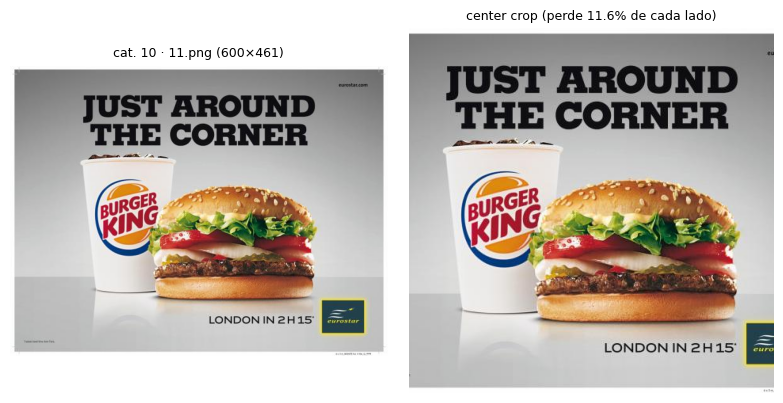

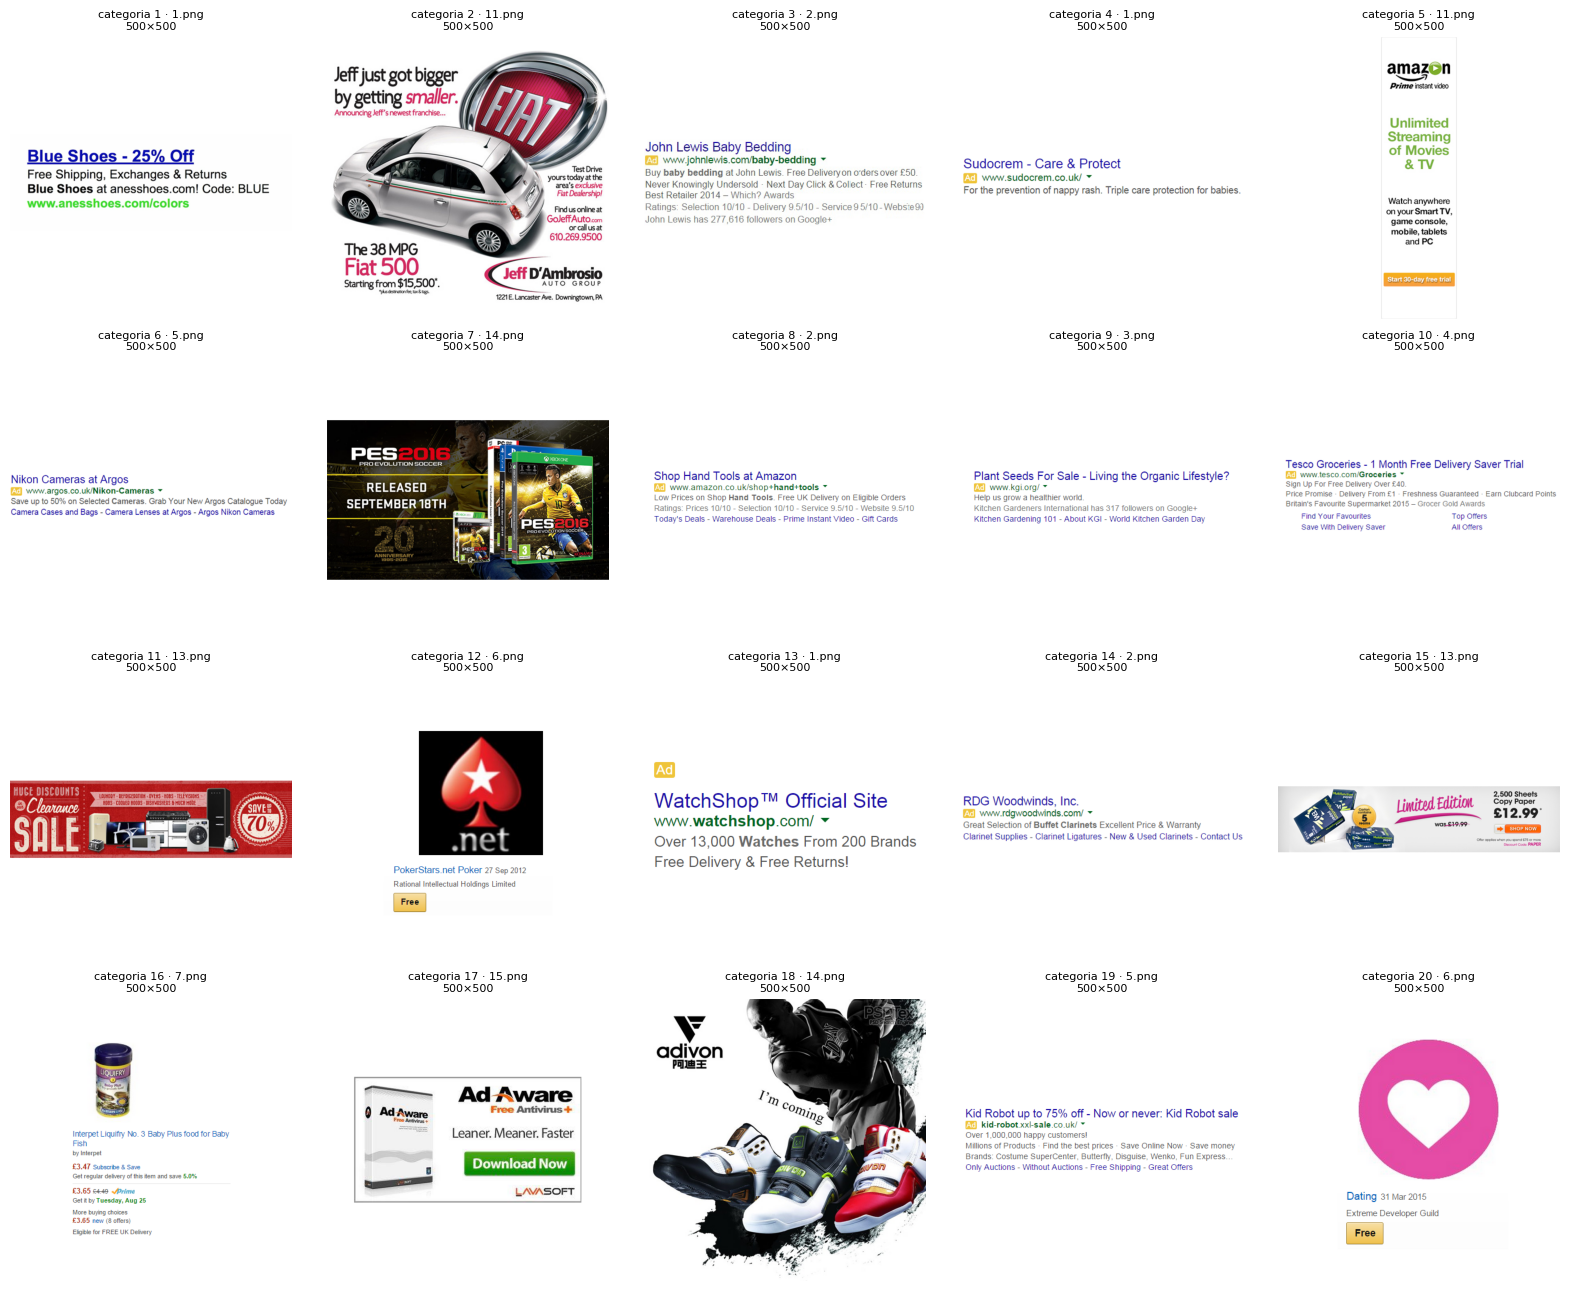

In [9]:
import matplotlib.pyplot as plt

# EDA do corpus, focada no que afeta o CLIP:
# * modo de cor / transparência: tratados em carregar_imagem (fundo branco);
# * proporção: o processor do CLIP redimensiona o menor lado para RESOLUCAO_CLIP e faz center
#   crop quadrado, então o lado maior perde (1 - menor/maior) da sua extensão, metade de cada lado
#   (a perda não depende da resolução);
# * resolução: anúncios de ~500 px são reduzidos para RESOLUCAO_CLIP, e texto pequeno pode ficar ilegível.
print("Modos de cor:", Counter(corpus["modo"]).most_common())
print(f"Com transparência (compostos sobre fundo branco): {int(corpus['transparente'].sum())} anúncios")
display(corpus[["largura", "altura", "proporcao"]].describe().round(2))

print("Tamanhos distintos (largura×altura):")
display((corpus["largura"].astype(str) + "×" + corpus["altura"].astype(str)).value_counts().to_frame("anúncios"))

menor = corpus[["largura", "altura"]].min(axis=1)
maior = corpus[["largura", "altura"]].max(axis=1)
corpus["perda_crop_por_lado"] = (1 - menor / maior) / 2
nao_quadrados = corpus[corpus["largura"] != corpus["altura"]]
print(f"Não quadrados: {len(nao_quadrados)} de {len(corpus)}; perda máxima no center crop: "
      f"{corpus['perda_crop_por_lado'].max():.1%} de cada lado do lado maior")

print(f"Redução de escala no CLIP: ~500 px -> {RESOLUCAO_CLIP} px (fator {RESOLUCAO_CLIP / 500:.2f})")

# Anúncios não quadrados: original × o quadrado central que o CLIP efetivamente vê
if len(nao_quadrados):
    fig, eixos = plt.subplots(len(nao_quadrados), 2, figsize=(8, 4 * len(nao_quadrados)), squeeze=False)
    for k, (_, r) in enumerate(nao_quadrados.iterrows()):
        img = carregar_imagem(r["caminho"])
        lado = min(img.size)
        esq, topo = (img.width - lado) // 2, (img.height - lado) // 2
        eixos[k, 0].imshow(img)
        eixos[k, 0].set_title(f"cat. {r['categoria']} · {r['n']}.png ({img.width}×{img.height})", fontsize=9)
        eixos[k, 1].imshow(img.crop((esq, topo, esq + lado, topo + lado)))
        eixos[k, 1].set_title(f"center crop (perde {r['perda_crop_por_lado']:.1%} de cada lado)", fontsize=9)
    for ax in eixos.flat:
        ax.axis("off")
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / "center_crop_nao_quadrados.png", dpi=120)
    plt.show()

# Anúncios com transparência: convert("RGB") direto × composição sobre fundo branco
transp = corpus[corpus["transparente"]]
if len(transp):
    fig, eixos = plt.subplots(2, len(transp), figsize=(2.6 * len(transp), 5.5), squeeze=False)
    for k, (_, r) in enumerate(transp.iterrows()):
        with Image.open(r["caminho"]) as img:
            eixos[0, k].imshow(img.convert("RGB"))
        eixos[1, k].imshow(carregar_imagem(r["caminho"]))
        eixos[0, k].set_title(f"cat. {r['categoria']} · {r['n']}.png ({r['modo']})", fontsize=8)
    eixos[0, 0].set_ylabel('convert("RGB")')
    eixos[1, 0].set_ylabel("fundo branco")
    for ax in eixos.flat:
        ax.set_xticks([]); ax.set_yticks([])
    plt.tight_layout()
    plt.show()

# Um anúncio sorteado por categoria (diversidade do corpus, R2)
exemplos = corpus.groupby("categoria").sample(n=1, random_state=SEED)
fig, eixos = plt.subplots(4, 5, figsize=(16, 13))
for ax, (_, r) in zip(eixos.flat, exemplos.iterrows()):
    ax.imshow(carregar_imagem(r["caminho"]))
    ax.set_title(f"categoria {r['categoria']} · {r['n']}.png\n{r['largura']}×{r['altura']}", fontsize=8)
    ax.axis("off")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "exemplos_por_categoria.png", dpi=120)
plt.show()

Com 301 anúncios, usar o corpus inteiro é a unica opçao já que o subconjunto não existe. 

* o ADS-16 tem 301 anúncios e que todos foram usados;
* o mínimo de 500 vale para subconjuntos, e por isso não se aplica;

Fotos pessoais têm outra distribuição: não têm logo, texto de marketing nem produto em destaque. Misturá-las inflaria o corpus com imagens que mudam o ranking. Por exemplo, "a smiling person" subiria artificialmente.


## Modelo CLIP e embeddings

[Checkpoint escolhido e por quê. Nenhum treino: só extração de embeddings.]

In [10]:
import torch
from transformers import CLIPModel, CLIPProcessor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Modelo e processor do MESMO checkpoint e revisão: o processor (resize, crop, normalização com a
# média/desvio do pré-treino, tokenização) tem que ser o que o modelo espera.
# * eval(): desliga o dropout, então a mesma imagem gera sempre o mesmo embedding;
# * fp32: ~1,7 GB cabe com folga na T4; fp16 pode mudar o cosseno na 3ª casa, perto do threshold;
# * pesos: o commit fixado só tem pytorch_model.bin (o model.safetensors existe apenas em PRs do
#   robô SFconvertbot, fora do commit). Por isso não dá para usar use_safetensors=True com a revisão
#   fixada (erro), e o transformers, ao carregar o .bin, baixaria em segundo plano o .safetensors de um
#   PR "para a próxima vez" (+1,7 GB, sem uso). A variável abaixo desliga essa conversão: os pesos
#   carregados são os do SHA fixado.
os.environ["DISABLE_SAFETENSORS_CONVERSION"] = "1"
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
modelo = CLIPModel.from_pretrained(CHECKPOINT_CLIP, revision=REVISAO_CLIP, dtype=torch.float32).to(DEVICE).eval()
processor = CLIPProcessor.from_pretrained(CHECKPOINT_CLIP, revision=REVISAO_CLIP)
TEMPOS.append({"etapa": "carregamento do CLIP", "segundos": round(time.perf_counter() - _t0, 1)})

# Verificações: checkpoint e processor são os esperados
crop = processor.image_processor.crop_size
pixels = processor(images=[carregar_imagem(corpus["caminho"].iloc[0])], return_tensors="pt")["pixel_values"]
assert modelo.config.projection_dim == DIM_EMBEDDING, modelo.config.projection_dim
assert (crop["height"], crop["width"]) == (RESOLUCAO_CLIP, RESOLUCAO_CLIP), crop
assert tuple(pixels.shape) == (1, 3, RESOLUCAO_CLIP, RESOLUCAO_CLIP), tuple(pixels.shape)

n_parametros = sum(p.numel() for p in modelo.parameters())
print(f"{CHECKPOINT_CLIP}@{REVISAO_CLIP[:7]} em {DEVICE}: {n_parametros / 1e6:.0f}M parâmetros, "
      f"entrada {tuple(pixels.shape)}, embedding de {DIM_EMBEDDING} dimensões")

# O que get_image_features devolve no transformers 5: um objeto, não um tensor
with torch.inference_mode():
    saida = modelo.get_image_features(pixel_values=pixels.to(DEVICE))
print(type(saida).__name__, {k: tuple(v.shape) for k, v in saida.items() if v is not None})
if DEVICE == "cuda":
    print(f"Pico de VRAM alocada: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/4.76k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 1.71GB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

openai/clip-vit-large-patch14-336@ce19dc9 em cuda: 428M parâmetros, entrada (1, 3, 336, 336), embedding de 768 dimensões
BaseModelOutputWithPooling {'last_hidden_state': (1, 577, 1024), 'pooler_output': (1, 768)}
Pico de VRAM alocada: 1.76 GB


In [11]:
import torch.nn.functional as F


def _projecao(saida) -> torch.Tensor:
    """Embedding no espaço compartilhado imagem-texto, a partir da saída de get_*_features.

    No transformers 5, get_image_features/get_text_features devolvem um BaseModelOutputWithPooling:
    .pooler_output já passou pela projeção (visual_projection/text_projection) e tem DIM_EMBEDDING
    dimensões. O primeiro campo ([0]) é o last_hidden_state, sem projeção (na imagem,
    (lote, 577 tokens, 1024)): usá-lo daria um embedding errado.
    """
    emb = saida if isinstance(saida, torch.Tensor) else saida.pooler_output
    assert emb.ndim == 2 and emb.shape[-1] == DIM_EMBEDDING, tuple(emb.shape)
    return emb


def embeddings_imagens(caminhos, tamanho_lote: int = TAMANHO_LOTE) -> torch.Tensor:
    """Embeddings L2-normalizados (N, DIM_EMBEDDING) na ordem de `caminhos`, em lotes (CPU, fp32).

    Em lotes porque o ViT-L/14 a 336 px tem 577 tokens por imagem: as 301 de uma vez pesariam na VRAM.
    """
    partes = []
    for i in range(0, len(caminhos), tamanho_lote):
        imagens = [carregar_imagem(c) for c in caminhos[i:i + tamanho_lote]]
        pixels = processor(images=imagens, return_tensors="pt")["pixel_values"].to(DEVICE)
        with torch.inference_mode():
            emb = _projecao(modelo.get_image_features(pixel_values=pixels))
        partes.append(F.normalize(emb, dim=-1).cpu())
    return torch.cat(partes)


def embeddings_textos(textos) -> torch.Tensor:
    """Embeddings L2-normalizados (N, DIM_EMBEDDING) de textos (CPU, fp32).

    padding=True completa as frases até a mais longa do lote; a attention_mask devolvida pelo
    processor faz o modelo ignorar esses tokens de padding (ver R14).
    """
    entrada = processor(text=list(textos), return_tensors="pt", padding=True).to(DEVICE)
    with torch.inference_mode():
        emb = _projecao(modelo.get_text_features(**entrada))
    return F.normalize(emb, dim=-1).cpu()

In [ ]:
# Embeddings normalizados das 301 imagens do corpus (só inferência, nenhum treino)
assert carregar_imagem.__module__ == "src.dados", carregar_imagem.__module__  # a função do src, com fundo branco

if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
_t0 = time.perf_counter()
EMB_IMAGENS = embeddings_imagens(corpus["caminho"].tolist())
pico_vram = torch.cuda.max_memory_allocated() / 1e9 if DEVICE == "cuda" else None
TEMPOS.append({"etapa": "embeddings das imagens", "segundos": round(time.perf_counter() - _t0, 1),
               "pico_vram_gb": None if pico_vram is None else round(pico_vram, 2)})

assert EMB_IMAGENS.shape == (len(corpus), DIM_EMBEDDING), tuple(EMB_IMAGENS.shape)
assert torch.allclose(EMB_IMAGENS.norm(dim=-1), torch.ones(len(corpus)), atol=1e-4)  # norma 1: produto = cosseno
print(f"Embeddings: {tuple(EMB_IMAGENS.shape)} em {TEMPOS[-1]['segundos']} s"
      + (f", pico de VRAM {pico_vram:.2f} GB" if pico_vram is not None else ""))

torch.save({"checkpoint": CHECKPOINT_CLIP, "revisao": REVISAO_CLIP,
            "caminho_rel": corpus["caminho_rel"].tolist(), "embeddings": EMB_IMAGENS},
           DIR_OUTPUTS / "embeddings_imagens.pt")

# Quase-duplicatas: o md5 só pega cópias exatas. Cosseno imagem-imagem entre todos os pares; os pares
# acima do limiar são mostrados lado a lado para inspeção visual (a decisão de manter ou remover é
# registrada no markdown do corpus). Também: o vizinho mais próximo do 1/16.png (arquivo extra da cat. 1).
LIMIAR_QUASE_DUPLICATA = 0.9
sim_ii = EMB_IMAGENS @ EMB_IMAGENS.T
sim_ii.fill_diagonal_(-1)
PARES_QUASE_DUPLICATAS = [tuple(par) for par in
                          (torch.triu(sim_ii, diagonal=1) >= LIMIAR_QUASE_DUPLICATA).nonzero().tolist()]
print(f"Pares com cosseno imagem-imagem >= {LIMIAR_QUASE_DUPLICATA}: {len(PARES_QUASE_DUPLICATAS)}")
k = corpus.index[(corpus["categoria"] == 1) & (corpus["n"] == 16)][0]
v = int(sim_ii[k].argmax())
print(f"Vizinho do 1/16.png: {corpus['caminho_rel'][v]} (cosseno {sim_ii[k, v]:.3f})")

pares_mostrados = sorted(PARES_QUASE_DUPLICATAS, key=lambda par: -float(sim_ii[par]))[:10]  # no máximo 10
if pares_mostrados:
    fig, eixos = plt.subplots(len(pares_mostrados), 2, figsize=(7, 3.5 * len(pares_mostrados)), squeeze=False)
    for linha, (a, b) in enumerate(pares_mostrados):
        for coluna, idx in enumerate((a, b)):
            r = corpus.iloc[idx]
            eixos[linha, coluna].imshow(carregar_imagem(r["caminho"]))
            eixos[linha, coluna].set_title(f"cat. {r['categoria']} · {r['n']}.png", fontsize=9)
            eixos[linha, coluna].axis("off")
        eixos[linha, 0].text(1.05, 1.08, f"cosseno {sim_ii[a, b]:.3f}", transform=eixos[linha, 0].transAxes,
                             ha="center", fontsize=10, fontweight="bold")
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / "quase_duplicatas.png", dpi=120)
    plt.show()

## 2.1 — Ranking de objetos por frequência semântica

### Descrições de objetos/conceitos (R3)

[As ≥ 20 descrições e o critério de escolha.]

In [ ]:
import numpy as np
import pandas as pd

# Conceitos (R3): objetos concretos, pessoas/cenários e elementos de design/marketing de anúncios.
# Critérios: um conceito por frase (o CLIP não faz "ou" lógico: "A or B" vira um vetor no meio dos
# dois, que pode não ficar perto de nenhum), sem quase-sinônimos, com artigo (como nas legendas do
# pré-treino) e em inglês (o CLIP da OpenAI foi treinado quase só com texto em inglês).
CONCEITOS = [
    # Objetos / produtos
    "a car", "a smartphone", "a laptop computer", "a perfume bottle", "a makeup product",
    "a plate of food", "a beverage can", "a pair of shoes", "fashion clothing", "a wrist watch",
    "a house", "furniture", "a credit card",
    # Pessoas e cenários
    "a smiling person", "a group of people", "a child", "an outdoor landscape", "an office",
    # Elementos de design e marketing
    "large bold text", "a brand logo", "a discount price tag", "social media icons",
    "a plain solid color background", "a futuristic technology background", "a hand holding a product",
]
assert len(CONCEITOS) >= 20 and len(set(CONCEITOS)) == len(CONCEITOS)

# Prompt ensembling (Radford et al., 2021, seção 3.1.4): média dos embeddings do mesmo conceito em
# vários templates, renormalizada (continua sendo cosseno). Templates genéricos, que fazem sentido
# para qualquer conceito da lista: um template específico ("a product shot of {}") puxaria todos os
# conceitos para "foto de produto" e mudaria o ranking pela forma de escrever, não pelo corpus.
TEMPLATES = ["a photo of {}.", "an advertisement showing {}.", "an image containing {}.", "{}"]


def obter_embeddings_conceitos(conceitos, templates) -> torch.Tensor:
    """(N, DIM_EMBEDDING): média dos embeddings dos templates de cada conceito, renormalizada."""
    medias = [embeddings_textos([t.format(c) for t in templates]).mean(dim=0) for c in conceitos]
    return F.normalize(torch.stack(medias), dim=-1)


_t0 = time.perf_counter()
EMB_CONCEITOS = obter_embeddings_conceitos(CONCEITOS, TEMPLATES)
TEMPOS.append({"etapa": "embeddings dos conceitos", "segundos": round(time.perf_counter() - _t0, 1)})
assert EMB_CONCEITOS.shape == (len(CONCEITOS), DIM_EMBEDDING), tuple(EMB_CONCEITOS.shape)
print(f"{len(CONCEITOS)} conceitos × {len(TEMPLATES)} templates -> embeddings {tuple(EMB_CONCEITOS.shape)}")

In [ ]:
# Cosseno imagem × conceito: os dois lados têm norma 1, então o produto interno é o cosseno.
MATRIZ_SIMILARIDADE = EMB_IMAGENS @ EMB_CONCEITOS.T   # (301 imagens, N conceitos)
assert MATRIZ_SIMILARIDADE.shape == (len(corpus), len(CONCEITOS))
S = MATRIZ_SIMILARIDADE.numpy()
print(f"Matriz imagens × conceitos: {S.shape}; cosseno de {S.min():.3f} a {S.max():.3f}")

### Threshold de similaridade (R4, R5)

[Valor escolhido e justificativa, com base na distribuição das similaridades.]

In [ ]:
# Threshold (R4, R5). O cosseno imagem-texto do CLIP fica numa faixa estreita e baixa, então o corte
# vem da distribuição observada, não de um número redondo. Evidências:
# (1) distribuição global e por conceito; (2) sensibilidade do top-5 ao threshold;
# (3) anúncios logo acima e logo abaixo do corte (célula seguinte).
# Sem softmax entre conceitos: ele força um rótulo por imagem (soma 1 mesmo se nenhum conceito se
# aplica), e "objetos que ocorrem" é multi-rótulo.
THRESHOLD = 0.17  # decisão a justificar no markdown com as evidências abaixo

print(f"Percentis do cosseno (todos os pares): 50% {np.percentile(S, 50):.3f} · 85% {np.percentile(S, 85):.3f}"
      f" · 95% {np.percentile(S, 95):.3f}")
print(f"Pares acima do threshold {THRESHOLD}: {(S >= THRESHOLD).sum()} de {S.size} ({(S >= THRESHOLD).mean():.1%})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={"width_ratios": [1, 1.3]})
ax1.hist(S.ravel(), bins=50, edgecolor="black", alpha=0.7)
ax1.axvline(THRESHOLD, color="red", ls="--", label=f"threshold {THRESHOLD}")
ax1.set(title="Todas as similaridades (imagens × conceitos)", xlabel="cosseno", ylabel="pares")
ax1.legend()
ordem = np.argsort(np.median(S, axis=0))
ax2.boxplot([S[:, j] for j in ordem], vert=False, tick_labels=[CONCEITOS[j] for j in ordem])
ax2.axvline(THRESHOLD, color="red", ls="--")
ax2.set(title="Por conceito (cada conceito tem a sua faixa)", xlabel="cosseno")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "distribuicao_similaridades.png", dpi=150)
plt.show()


def top_k_frequencia(threshold: float, k: int = 5) -> list:
    """Os k conceitos mais frequentes (cosseno >= threshold); desempate pela similaridade média."""
    freq = (S >= threshold).sum(axis=0)
    return [CONCEITOS[j] for j in np.lexsort((-S.mean(axis=0), -freq))[:k]]


# Sensibilidade: o top-5 por frequência muda se o threshold variar?
variacoes = np.round(THRESHOLD + np.array([-0.02, -0.01, 0.0, 0.01, 0.02]), 3)
sensibilidade = pd.DataFrame({f"t = {t}": top_k_frequencia(t) for t in variacoes}, index=range(1, 6))
display(sensibilidade)

In [ ]:
# Casos na fronteira (R5): para os 3 conceitos mais frequentes, os 3 anúncios logo abaixo e os 3 logo
# acima do threshold. Se o corte separa bem presença de ausência, os de cima mostram o conceito e os
# de baixo não.
CONCEITOS_FRONTEIRA = top_k_frequencia(THRESHOLD, k=3)
fig, eixos = plt.subplots(len(CONCEITOS_FRONTEIRA), 6, figsize=(17, 3.4 * len(CONCEITOS_FRONTEIRA)), squeeze=False)
for i, conceito in enumerate(CONCEITOS_FRONTEIRA):
    s = S[:, CONCEITOS.index(conceito)]
    abaixo = np.where(s < THRESHOLD)[0]
    acima = np.where(s >= THRESHOLD)[0]
    abaixo = abaixo[np.argsort(s[abaixo])][-3:]   # os 3 maiores abaixo do corte (em ordem crescente)
    acima = acima[np.argsort(s[acima])][:3]       # os 3 menores acima do corte
    for k, (idx, lado) in enumerate([(a, "abaixo") for a in abaixo] + [(a, "acima") for a in acima]):
        r = corpus.iloc[idx]
        ax = eixos[i, k]
        ax.imshow(carregar_imagem(r["caminho"]))
        ax.set_title(f"{lado} · cat. {r['categoria']} · {r['n']}.png\ncos {s[idx]:.3f}", fontsize=8,
                     color="tab:green" if lado == "acima" else "tab:red")
        ax.axis("off")
    eixos[i, 0].text(-0.05, 0.5, conceito, transform=eixos[i, 0].transAxes, rotation=90,
                     ha="right", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "threshold_fronteira.png", dpi=120)
plt.show()

### Ranking (R6)

In [ ]:
# Ranking (R6): ordenado pela frequência (nº de anúncios com cosseno >= THRESHOLD), como pede o
# enunciado; desempate pela similaridade média. Duas médias, porque medem coisas diferentes:
# * sim_media_corpus: média sobre os 301 anúncios ("afinidade de base" da frase com qualquer anúncio);
# * sim_media_acima: média só nos anúncios acima do threshold (força quando o conceito ocorre).
acima = S >= THRESHOLD
COL_FREQ = f"freq (cos >= {THRESHOLD})"
df_ranking = pd.DataFrame({
    "conceito": CONCEITOS,
    COL_FREQ: acima.sum(axis=0),
    "freq_%": 100 * acima.mean(axis=0),
    "sim_media_corpus": S.mean(axis=0),
    "sim_media_acima": [S[acima[:, j], j].mean() if acima[:, j].any() else np.nan for j in range(len(CONCEITOS))],
}).sort_values([COL_FREQ, "sim_media_corpus"], ascending=False).reset_index(drop=True)
df_ranking.index += 1
df_ranking.to_csv(DIR_REPORT_ASSETS / "ranking_frequencia_semantica.csv", index_label="posicao")
display(df_ranking.round(3))

In [ ]:
# Sensibilidade ao template: o ranking mede o corpus ou a forma como as frases foram escritas?
# Para cada conceito, a sobreposição entre os 15 anúncios mais similares (15 = tamanho de uma
# categoria) com o ensemble de templates e com um único template neutro ("a photo of {}.").
# Sobreposição alta = o conceito aponta para os mesmos anúncios, independentemente do template.
emb_neutro = embeddings_textos([f"a photo of {c}." for c in CONCEITOS])
S_neutro = (EMB_IMAGENS @ emb_neutro.T).numpy()
K_SOBREPOSICAO = 15
sobreposicao = [len(set(np.argsort(S[:, j])[-K_SOBREPOSICAO:]) & set(np.argsort(S_neutro[:, j])[-K_SOBREPOSICAO:]))
                / K_SOBREPOSICAO for j in range(len(CONCEITOS))]
df_template = pd.DataFrame({"conceito": CONCEITOS, f"sobreposição top-{K_SOBREPOSICAO}": sobreposicao,
                            "sim_media_ensemble": S.mean(axis=0), "sim_media_neutro": S_neutro.mean(axis=0)})
display(df_template.sort_values(f"sobreposição top-{K_SOBREPOSICAO}").round(3))

### Os 5 objetos mais encontrados (R7)

In [ ]:
# Os 5 conceitos mais frequentes (R7): para cada um, os 4 anúncios de maior similaridade e 1 anúncio
# na fronteira (o de menor similaridade que ainda conta para a frequência): o caso mais fraco mostra
# melhor do que o mais forte se a frequência é confiável.
NOMES_CATEGORIAS = {}  # nº da categoria -> nome do produto (preencher a partir do artigo em Documents/)


def rotulo_categoria(categoria: int) -> str:
    return NOMES_CATEGORIAS.get(categoria, f"cat. {categoria}")


TOP5_CONCEITOS = df_ranking["conceito"].head(5).tolist()
print("Os 5 conceitos mais frequentes:", TOP5_CONCEITOS)

fig, eixos = plt.subplots(5, 5, figsize=(16, 17))
for i, conceito in enumerate(TOP5_CONCEITOS):
    s = S[:, CONCEITOS.index(conceito)]
    melhores = list(np.argsort(s)[::-1][:4])
    acima_t = np.where(s >= THRESHOLD)[0]
    # anúncio na fronteira: o de menor cosseno acima do threshold (se nenhum passa, o 5º mais similar)
    fronteira = int(acima_t[np.argmin(s[acima_t])]) if len(acima_t) else int(np.argsort(s)[::-1][4])
    for k, idx in enumerate(melhores + [fronteira]):
        r = corpus.iloc[idx]
        ax = eixos[i, k]
        ax.imshow(carregar_imagem(r["caminho"]))
        cabecalho = f"{i + 1}. {conceito}\n" if k == 0 else ("fronteira\n" if k == 4 else "\n")
        ax.set_title(f"{cabecalho}{rotulo_categoria(r['categoria'])} · {r['n']}.png · cos {s[idx]:.3f}", fontsize=8)
        ax.axis("off")
plt.tight_layout()
fig.savefig(DIR_REPORT_ASSETS / "top5_conceitos_exemplos.png", dpi=120)
plt.show()

**Interpretação do ranking.** [O que o ranking mostra sobre o corpus.]

## 2.2 — Busca semântica por consulta textual

### Função de busca (R8)

In [ ]:
def buscar_anuncios(consulta: str, top_n: int = 5):
    """Índices (no `corpus`) e cossenos das top_n imagens mais similares a uma consulta textual (R8).

    A consulta entra como está, sem templates: é a frase que o usuário digitaria. (O ranking usa
    prompt ensembling porque ali cada conceito é uma descrição curta escrita para medir frequência.)
    """
    scores = (EMB_IMAGENS @ embeddings_textos([consulta]).T).squeeze(1).numpy()  # norma 1: cosseno
    top_indices = np.argsort(scores)[::-1][:top_n]
    return top_indices, scores[top_indices]

### Consultas (R9)

[As ≥ 8 consultas, organizadas de genérico → específico e de concreto → abstrato.]

In [ ]:
# Consultas (R9): variam em especificidade (genérica -> específica) e abstração (concreta -> abstrata).
# A última testa se o CLIP lê o texto impresso no anúncio ou só reconhece o layout.
CONSULTAS = pd.DataFrame([
    ("a car", "genérica", "concreta"),
    ("a luxury red sports car driving fast", "específica", "concreta"),
    ("a wrist watch", "genérica", "concreta"),
    ("a minimalist luxury wrist watch close-up", "específica", "concreta"),
    ("a happy smiling woman", "genérica", "concreta"),
    ("a professional businesswoman working on a computer", "específica", "concreta"),
    ("a discount promotion", "genérica", "intermediária"),
    ("special offer with a high percentage discount", "específica", "intermediária"),
    ("luxury", "genérica", "abstrata"),
    ("freedom and adventure", "genérica", "abstrata"),
    ("a healthy lifestyle", "intermediária", "abstrata"),
    ('the word "SALE" written in large letters', "específica", "texto impresso"),
], columns=["consulta", "especificidade", "abstração"])
CONSULTAS.index += 1
display(CONSULTAS)

resultados = []
for q, linha in CONSULTAS.iterrows():
    indices, scores = buscar_anuncios(linha["consulta"], top_n=5)
    duplicatas_no_top5 = [par for par in PARES_QUASE_DUPLICATAS if set(par) <= set(indices.tolist())]

    fig, eixos = plt.subplots(1, 5, figsize=(15, 3.4))
    fig.suptitle(f'Busca {q}: "{linha["consulta"]}" ({linha["especificidade"]}, {linha["abstração"]})',
                 fontsize=12, fontweight="bold", y=1.04)
    for pos_top, (idx, score) in enumerate(zip(indices, scores), start=1):
        r = corpus.iloc[idx]
        eixos[pos_top - 1].imshow(carregar_imagem(r["caminho"]))
        eixos[pos_top - 1].set_title(f"{pos_top}º · {rotulo_categoria(r['categoria'])} · {r['n']}.png\ncos {score:.3f}",
                                     fontsize=9)
        eixos[pos_top - 1].axis("off")
        resultados.append({"consulta": q, "texto": linha["consulta"], "posicao": pos_top,
                           "categoria": r["categoria"], "n": r["n"], "cosseno": round(float(score), 4)})
    plt.tight_layout()
    fig.savefig(DIR_REPORT_ASSETS / f"busca_q{q}.png", dpi=120, bbox_inches="tight")
    plt.show()
    if duplicatas_no_top5:
        print(f"  Atenção: quase-duplicatas no top-5: {duplicatas_no_top5}")

# Registro dos resultados (R10): uma linha por consulta × posição
df_busca = pd.DataFrame(resultados)
df_busca.to_csv(DIR_REPORT_ASSETS / "busca_resultados.csv", index=False)
display(df_busca.pivot(index="consulta", columns="posicao", values="cosseno"))

### Análise das consultas (R11)

[Para cada consulta: recuperou o que descreve ou interpretou de forma inesperada? Por quê?]

## Discussão (R12, R13, R14)

### Alinhamento das representações visuais e textuais (R12)

[texto]

### Por que o pré-treino contrastivo permite recuperação sem treino supervisionado (R13)

[texto]

### Consulta textual do CLIP × tokenização no BERT: padding e attention mask (R14)

[texto]

## Apêndice: versões e tempo/memória (R15)

In [20]:
# [versões das bibliotecas e resumo de tempo e memória, como na A1]